In [1]:
import csv
input_file= "symptoms_all.csv"
output_file="symptoms_all_variables.csv"
with open(input_file, 'r') as csvfile:
    with open(output_file, 'w', newline='') as f:
        spamreader = csv.reader(csvfile, delimiter=',')
        for row in spamreader:
            need = [row[8],row[22],row[25],row[37],row[45],row[47],row[64],row[101], row[116], row[253], row[280]]
            len_need = len(need)
            for i in range(len_need):
                if need[i] == '':
                   need[i] = "0"
                elif need[i] == 'y':
                   need[i] = "1"
                else:
                   continue

            if need[0] == 'y':
               need[0] = "1"
            #print(need)



            thewriter = csv.writer(f)
            thewriter.writerow(need)
            #f.write("%s %s %s %s %s %s %s %s %s %s %s\n" %(need[8],need[22],need[25],need[37],need[45],need[47],need[64],need[101], need[116], need[248], need[279]))

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import metrics
from patsy import dmatrices
import statsmodels.api as sm
from keras.layers import Dense
from keras.models import Model
import matplotlib.pyplot as plt
from keras.layers import Dropout
from keras.layers import Flatten
from tensorflow.keras.optimizers import SGD
from keras.layers import Flatten
from nltk.corpus import stopwords
from sklearn import datasets, svm
from keras.models import Sequential
from keras.layers import Embedding
from pandas import Series, DataFrame
from keras.layers import MaxPooling1D
from gensim.models import KeyedVectors
from tensorflow.keras.utils import to_categorical
from sklearn.linear_model import SGDClassifier
from keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.nonparametric import smoothers_lowess
from keras.preprocessing.sequence import pad_sequences
from statsmodels.nonparametric.kde import KDEUnivariate
from keras.layers import Conv1D, GlobalMaxPooling1D, Conv2D, MaxPooling2D
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.naive_bayes import MultinomialNB

import re
import nltk
import gensim
import logging
import bs4 as bs
import urllib.request
import multiprocessing
import texthero as hero
from gensim import utils
from sklearn import utils
from hyperas import optim
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
tqdm.pandas(desc="progress-bar")
from gensim.models import Doc2Vec
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.metrics import accuracy_score
from hyperopt import Trials, STATUS_OK, tpe
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from gensim.models.doc2vec import TaggedDocument
from hyperas.distributions import choice, uniform
from gensim.models.doc2vec import LabeledSentence
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import cross_val_score
from keras import models
from keras import layers
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize, word_tokenize

dataset = pd.read_csv(output_file)
dataset

,female,tuber,diabetes,men_con,cough,ch_cough,diarr,exc_urine,exc_drink,disease_description,finaldiagnosis
0,0,1,0,0,1,1,0,0,1,The deceased developed blisters under the righ...,0.0
1,1,0,0,0,1,1,1,0,0,At first the deceased was complaining about br...,0.0
2,1,1,0,0,1,1,0,0,1,She was complaining about hot feet with swelli...,0.0
3,1,0,0,0,0,0,0,0,0,At first deceased complained headache and stom...,0.0
4,0,0,0,1,0,0,0,0,1,Beginning of illness deceased dreamed eating f...,0.0
...,...,...,...,...,...,...,...,...,...,...,...
8693,1,0,0,0,0,0,0,0,0,She started by complaining with headache and a...,0.0
8694,0,0,0,0,0,0,0,0,0,0,0.0
8695,1,0,0,0,0,0,0,0,0,The deceased started by having painful abdomen...,0.0
8696,0,0,0,0,0,0,0,0,0,0,0.0


In [3]:
import numpy as np
from numpy import NAN

dataset1 = dataset[~(dataset["disease_description"] == '0')]
dataset1

,female,tuber,diabetes,men_con,cough,ch_cough,diarr,exc_urine,exc_drink,disease_description,finaldiagnosis
0,0,1,0,0,1,1,0,0,1,The deceased developed blisters under the righ...,0.0
1,1,0,0,0,1,1,1,0,0,At first the deceased was complaining about br...,0.0
2,1,1,0,0,1,1,0,0,1,She was complaining about hot feet with swelli...,0.0
3,1,0,0,0,0,0,0,0,0,At first deceased complained headache and stom...,0.0
4,0,0,0,1,0,0,0,0,1,Beginning of illness deceased dreamed eating f...,0.0
...,...,...,...,...,...,...,...,...,...,...,...
8691,1,1,0,1,1,1,1,0,0,"She started by coughing, fever and have diarrh...",0.0
8692,1,0,0,0,1,0,0,0,0,The deceased started by coughing where she was...,0.0
8693,1,0,0,0,0,0,0,0,0,She started by complaining with headache and a...,0.0
8695,1,0,0,0,0,0,0,0,0,The deceased started by having painful abdomen...,0.0


In [4]:
finaldiagnosis = dataset1[dataset1['finaldiagnosis'] == 1.0]
finaldiagnosis.count()

female                 77
tuber                  77
diabetes               77
men_con                77
cough                  77
ch_cough               77
diarr                  77
exc_urine              77
exc_drink              77
disease_description    77
finaldiagnosis         77
dtype: int64

In [5]:
dataset1.finaldiagnosis = dataset1.finaldiagnosis.astype(int)
dataset1

/home/vmuser/anaconda3/lib/python3.6/site-packages/pandas/core/generic.py:5170: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,female,tuber,diabetes,men_con,cough,ch_cough,diarr,exc_urine,exc_drink,disease_description,finaldiagnosis
0,0,1,0,0,1,1,0,0,1,The deceased developed blisters under the righ...,0
1,1,0,0,0,1,1,1,0,0,At first the deceased was complaining about br...,0
2,1,1,0,0,1,1,0,0,1,She was complaining about hot feet with swelli...,0
3,1,0,0,0,0,0,0,0,0,At first deceased complained headache and stom...,0
4,0,0,0,1,0,0,0,0,1,Beginning of illness deceased dreamed eating f...,0
...,...,...,...,...,...,...,...,...,...,...,...
8691,1,1,0,1,1,1,1,0,0,"She started by coughing, fever and have diarrh...",0
8692,1,0,0,0,1,0,0,0,0,The deceased started by coughing where she was...,0
8693,1,0,0,0,0,0,0,0,0,She started by complaining with headache and a...,0
8695,1,0,0,0,0,0,0,0,0,The deceased started by having painful abdomen...,0


In [6]:
#dataset1.to_csv('NewVA.csv', index=False)

In [7]:
#import numpy
#dataset1 = dataset.replace("#NULL!",numpy.NAN)
#dataset = dataset.replace(numpy.NAN,-1)
#NAN Values
#np.nan_to_num(dataset)

In [8]:
dataset1 = dataset1.reset_index()

In [9]:
#Divide train_data into input and target values
x1 = dataset1.drop("finaldiagnosis", axis = 1)
x = x1.drop("disease_description", axis = 1)
y = dataset1["finaldiagnosis"]
x, y

(      index  female  tuber  diabetes  men_con  cough  ch_cough  diarr  \
 0         0       0      1         0        0      1         1      0   
 1         1       1      0         0        0      1         1      1   
 2         2       1      1         0        0      1         1      0   
 3         3       1      0         0        0      0         0      0   
 4         4       0      0         0        1      0         0      0   
 ...     ...     ...    ...       ...      ...    ...       ...    ...   
 7828   8691       1      1         0        1      1         1      1   
 7829   8692       1      0         0        0      1         0      0   
 7830   8693       1      0         0        0      0         0      0   
 7831   8695       1      0         0        0      0         0      0   
 7832   8697       1      0         0        0      0         0      0   
 
       exc_urine  exc_drink  
 0             0          1  
 1             0          0  
 2             0    

In [10]:
#from imblearn.pipeline import make_pipeline
from imblearn import datasets
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import recall_score, roc_auc_score, precision_score, f1_score
import pandas as pd
import numpy as np

In [11]:
# Using SMOTE with Cross Validation
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Baseline no oversampling
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=45)
rf = RandomForestClassifier(n_estimators=100, random_state=13)
cross_val_score(rf, x_train, y_train, cv=kf, scoring = "recall")

array([0.54545455, 0.27272727, 0.33333333, 0.5       , 0.36363636])

In [12]:
# Lets make SMOTE-ing part of our cross validation
# Manual upsampling within folds

# 1. Random Forest

example_params = {'n_estimators': 100, 'max_depth': 5, 'random_state': 13}
params = {'n_estimators': [50, 100, 200], 'max_depth': [4, 6, 10, 12], 'random_state': [13]}

def score_model(model, params, cv=None):
    if cv is None:
        cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

    smoter = SMOTETomek(random_state=42)
    
    scores1 = []
    scores2 = []
    scores3 = []
    scores4 = []
    scores5 = []
    

    for train_fold_index, val_fold_index in cv.split(x_train, y_train):
        x_train_fold, x_val_fold = x_train.iloc[train_fold_index], x_train.iloc[val_fold_index]
        y_train_fold, y_val_fold = y_train.iloc[train_fold_index], y_train.iloc[val_fold_index]

        x_train_fold_upsample, y_train_fold_upsample = smoter.fit_resample(x_train_fold, y_train_fold)
        
        model_obj = model(**params).fit(x_train_fold_upsample, y_train_fold_upsample)
        
        score1 = recall_score(y_val_fold, model_obj.predict(x_val_fold))
        score2 = precision_score(y_val_fold, model_obj.predict(x_val_fold))
        score3 = f1_score(y_val_fold, model_obj.predict(x_val_fold))
        score4 = roc_auc_score(y_val_fold, model_obj.predict(x_val_fold))
        score5 = accuracy_score(y_val_fold, model_obj.predict(x_val_fold))
        
        scores1.append(score1)
        scores2.append(score2)
        scores3.append(score3)
        scores4.append(score4)
        scores5.append(score5)
        
        dfrf1 = pd.DataFrame(scores1)
        dfrf2 = pd.DataFrame(scores2)
        dfrf3 = pd.DataFrame(scores3)
        dfrf4 = pd.DataFrame(scores4)
        dfrf5 = pd.DataFrame(scores5)
        
        dfrf11 = dfrf1.mean(axis=0)
        dfrf12 = dfrf2.mean(axis=0)
        dfrf13 = dfrf3.mean(axis=0)
        dfrf14 = dfrf4.mean(axis=0)
        dfrf15 = dfrf5.mean(axis=0)
    return dfrf11, dfrf12, dfrf13, dfrf14, dfrf15

# Example of the model in action
score_model(RandomForestClassifier, example_params, cv=kf)

(0    0.756061
 dtype: float64,
 0    0.188237
 dtype: float64,
 0    0.277856
 dtype: float64,
 0    0.85422
 dtype: float64,
 0    0.95046
 dtype: float64)

In [13]:
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [14]:
# Lets see results over the test set

x_train_upsample, y_train_upsample = SMOTETomek(random_state=42).fit_resample(x_train, y_train)


rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=13)
rf.fit(x_train_upsample, y_train_upsample)
recalltest = recall_score(y_test, rf.predict(x_test))
precisiontest = precision_score(y_test, rf.predict(x_test))
f1test = f1_score(y_test, rf.predict(x_test))
roc_auctest = roc_auc_score(y_test, rf.predict(x_test))
accuracytest = accuracy_score(y_test, rf.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

(0.95,
 0.2638888888888889,
 0.41304347826086957,
 0.9613331614234141,
 0.9724349157733537)

In [15]:
# 5. XGBOOST

from xgboost import XGBClassifier
xgclass = XGBClassifier
from imblearn.over_sampling import RandomOverSampler

example_params1 = {'max_depth':6, 'eta': 0.3, 'gamma': 0, 'n_estimators': 100}

params = {'max_depth': [3, 6, 10, 20], 'eta': [0.01,0.05,0.1, 0.3], 'gamma': np.arange(0, 10, 1), 'n_estimators': [50, 100, 150]}


def score_model(model, params, cv=None):
    if cv is None:
        cv = KFold(n_splits=5, random_state=42)

    smoter = SMOTETomek(random_state=42)
    
    scores1 = []
    scores2 = []
    scores3 = []
    scores4 = []
    scores5 = []
    

    for train_fold_index, val_fold_index in cv.split(x_train, y_train):
        x_train_fold, x_val_fold = x_train.iloc[train_fold_index], x_train.iloc[val_fold_index]
        y_train_fold, y_val_fold = y_train.iloc[train_fold_index], y_train.iloc[val_fold_index]

        x_train_fold_upsample, y_train_fold_upsample = smoter.fit_resample(x_train_fold, y_train_fold)
        
        model_obj = model(**params).fit(x_train_fold_upsample, y_train_fold_upsample)
        
        score1 = recall_score(y_val_fold, model_obj.predict(x_val_fold))
        score2 = precision_score(y_val_fold, model_obj.predict(x_val_fold))
        score3 = f1_score(y_val_fold, model_obj.predict(x_val_fold))
        score4 = roc_auc_score(y_val_fold, model_obj.predict(x_val_fold))
        score5 = accuracy_score(y_val_fold, model_obj.predict(x_val_fold))
          
        scores1.append(score1)
        scores2.append(score2)
        scores3.append(score3)
        scores4.append(score4)
        scores5.append(score5)
        
        dfxgclass1 = pd.DataFrame(scores1)
        dfxgclass2 = pd.DataFrame(scores2)
        dfxgclass3 = pd.DataFrame(scores3)
        dfxgclass4 = pd.DataFrame(scores4)
        dfxgclass5 = pd.DataFrame(scores5)
        
        dfxgclass11 = dfxgclass1.mean(axis=0)
        dfxgclass12 = dfxgclass2.mean(axis=0)
        dfxgclass13 = dfxgclass3.mean(axis=0)
        
# Example of the model in action
score_model(xgclass, example_params1, cv=kf)

/home/vmuser/anaconda3/lib/python3.6/site-packages/xgboost/sklearn.py:1146: UserWarning:

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].



[13:29:19] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/home/vmuser/anaconda3/lib/python3.6/site-packages/xgboost/sklearn.py:1146: UserWarning:

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].



[13:29:19] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/home/vmuser/anaconda3/lib/python3.6/site-packages/xgboost/sklearn.py:1146: UserWarning:

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].



[13:29:20] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/home/vmuser/anaconda3/lib/python3.6/site-packages/xgboost/sklearn.py:1146: UserWarning:

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].



[13:29:20] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/home/vmuser/anaconda3/lib/python3.6/site-packages/xgboost/sklearn.py:1146: UserWarning:

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].



[13:29:20] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [16]:
# Lets see how it compares to the test data

x_train_upsample, y_train_upsample = SMOTETomek(random_state=42).fit_resample(x_train, y_train)

xgclass = XGBClassifier(max_depth = 6, eta = 0.3, gamma = 0, n_estimators = 100)
xgclass.fit(x_train_upsample, y_train_upsample)

recalltest = recall_score(y_test, xgclass.predict(x_test))
precisiontest = precision_score(y_test, xgclass.predict(x_test))
f1test = f1_score(y_test, xgclass.predict(x_test))
roc_auctest = roc_auc_score(y_test, xgclass.predict(x_test))
accuracytest = accuracy_score(y_test, xgclass.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

/home/vmuser/anaconda3/lib/python3.6/site-packages/xgboost/sklearn.py:1146: UserWarning:

The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].



[13:29:24] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


(0.7,
 0.0915032679738562,
 0.16184971098265896,
 0.8141567818463126,
 0.9259826442062277)

In [19]:
# Neural Network
np.random.seed(0)

number_of_features= 10

#Create function returning a compiled network
def create_network():
   
    # Start neural network
    network = models.Sequential()

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu', input_shape=(number_of_features,)))

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu'))
    
     # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu'))

    
    # Add fully connected layer with a sigmoid activation function
    network.add(layers.Dense(units=1, activation='sigmoid'))

    # Compile neural network
    network.compile(loss='binary_crossentropy', # Cross-entropy
                    optimizer='rmsprop', # Root Mean Square Propagation
                    metrics=['accuracy']) # Accuracy performance metric
   
    # Return compiled network
    return network

In [21]:
# Wrap Keras model so it can be used by scikit-learn


from keras.wrappers.scikit_learn import KerasClassifier

neural_network = KerasClassifier(build_fn=create_network, epochs=10, batch_size=100, verbose=0)
neural_network._estimator_type = "classifier"

#neural_network._estimator_type = "classifier"
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=45)

# Evaluate neural network using 5-fold cross-validation
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

example_params3 = {'batch_size':10, 'epochs':100}

params = {'batch_size': [10, 20, 40, 60, 80], 'epochs': [10, 20, 50, 100]}

# Evaluate model
def score_model(model, params, cv=None):
    if cv is None:
        cv = KFold(n_splits=5, random_state=42)

    smoter = SMOTETomek(random_state=42)
   
    scores1 = []
    scores2 = []
    scores3 = []
    scores4 = []
    scores5 = []
   

    for train_fold_index, val_fold_index in cv.split(x_train, y_train):
        x_train_fold, x_val_fold = x_train.iloc[train_fold_index], x_train.iloc[val_fold_index]
        y_train_fold, y_val_fold = y_train.iloc[train_fold_index], y_train.iloc[val_fold_index]

        x_train_fold_upsample, y_train_fold_upsample = smoter.fit_resample(x_train_fold, y_train_fold)
       
        model_obj = model.fit(x_train_fold_upsample, y_train_fold_upsample)
       
        score1 = recall_score(y_val_fold, model.predict(x_val_fold))
        score2 = precision_score(y_val_fold, model.predict(x_val_fold))
        score3 = f1_score(y_val_fold, model.predict(x_val_fold))
        score4 = roc_auc_score(y_val_fold, model.predict(x_val_fold))
        score5 = accuracy_score(y_val_fold, model.predict(x_val_fold))
         
        scores1.append(score1)
        scores2.append(score2)
        scores3.append(score3)
        scores4.append(score4)
        scores5.append(score5)
       
        dfnn1 = pd.DataFrame(scores1)
        dfnn2 = pd.DataFrame(scores2)
        dfnn3 = pd.DataFrame(scores3)
        dfnn4 = pd.DataFrame(scores4)
        dfnn5 = pd.DataFrame(scores5)
       
        dfnn11 = dfnn1.mean(axis=0)
        dfnn12 = dfnn2.mean(axis=0)
        dfnn13 = dfnn3.mean(axis=0)
        dfnn14 = dfnn4.mean(axis=0)
        dfnn15 = dfnn5.mean(axis=0)

    return dfnn11, dfnn12, dfnn13, dfnn14, dfnn15

# Example of the model in action
# print(type(neural_network))
score_model(neural_network, example_params3, cv=kf)

/home/vmuser/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



(0    0.528788
 dtype: float64,
 0    0.005662
 dtype: float64,
 0    0.011203
 dtype: float64,
 0    0.486134
 dtype: float64,
 0    0.444594
 dtype: float64)

In [22]:
#How it compares to the test data

x_train_upsample, y_train_upsample = SMOTETomek(random_state=42).fit_resample(x_train, y_train)

neural_network.fit(x_train_upsample, y_train_upsample)

recalltest = recall_score(y_test, neural_network.predict(x_test))
precisiontest = precision_score(y_test, neural_network.predict(x_test))
f1test = f1_score(y_test, neural_network.predict(x_test))
roc_auctest = roc_auc_score(y_test, neural_network.predict(x_test))
accuracytest = accuracy_score(y_test, neural_network.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

(1.0,
 0.011409013120365089,
 0.022560631697687537,
 0.5531201650335225,
 0.1153649821337417)

In [23]:
#No Oversampling
#How it compares to the test data

x_train_upsample, y_train_upsample = SMOTETomek(random_state=42).fit_resample(x_train, y_train)

neural_network.fit(x_train, y_train)

recalltest = recall_score(y_test, neural_network.predict(x_test))
precisiontest = precision_score(y_test, neural_network.predict(x_test))
f1test = f1_score(y_test, neural_network.predict(x_test))
roc_auctest = roc_auc_score(y_test, neural_network.predict(x_test))
accuracytest = accuracy_score(y_test, neural_network.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

/home/vmuser/anaconda3/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1248: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



(0.0, 0.0, 0.0, 0.5, 0.9897907095456866)

In [24]:
#Calculating the class weight
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight("balanced",
                                    classes=np.unique(y_train),
                                    y=y_train)

class_weights

array([ 0.50489943, 51.52631579])

In [25]:
#Class_weight.compute_class_weight produces an array, we need to change it to a dict in order to work with Keras
class_weights = dict(enumerate(class_weights))
class_weights

{0: 0.5048994326972667, 1: 51.526315789473685}

In [26]:
#Neural Network  #Cost-Sensitive Classification
np.random.seed(0)
number_of_features= 10

#Create function returning a compiled network
def create_network1():
    
    # Start neural network
    network = models.Sequential()

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu', input_shape=(number_of_features,)))

    # Add fully connected layer with a ReLU activation function
    network.add(layers.Dense(units=16, activation='relu'))

    # Add fully connected layer with a sigmoid activation function
    network.add(layers.Dense(units=1, activation='sigmoid'))

    # Compile neural network
    network.compile(loss='binary_crossentropy', # Cross-entropy
                    optimizer='rmsprop', # Root Mean Square Propagation
                    metrics=['accuracy']) # Accuracy performance metric
    
    # Return compiled network
    return network

In [29]:
neural_network1 = KerasClassifier(build_fn=create_network1, epochs=100, batch_size=32, verbose=0)
neural_network1._estimator_type = "classifier"

# Use the same function above for the validation set
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size = 0.25,  stratify=y_train)


neural_network1.fit(x_train, y_train,
                               validation_data=(x_valid, y_valid),
                               epochs=100,
                               class_weight=class_weights)
recalltest = recall_score(y_test, neural_network1.predict(x_test))
precisiontest = precision_score(y_test, neural_network1.predict(x_test))
f1test = f1_score(y_test, neural_network1.predict(x_test))
roc_auctest = roc_auc_score(y_test, neural_network1.predict(x_test))
accuracytest = accuracy_score(y_test, neural_network1.predict(x_test))

recalltest, precisiontest, f1test, roc_auctest, accuracytest

(0.3, 0.25, 0.2727272727272727, 0.6453584321815369, 0.9836651352730985)

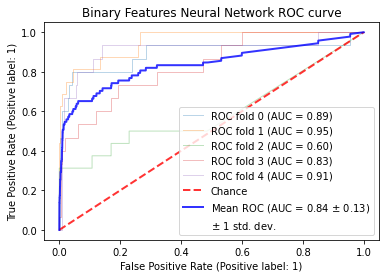

In [50]:
from sklearn import svm, datasets
from sklearn.metrics import auc
from sklearn.metrics import plot_roc_curve

cv = StratifiedKFold(n_splits=5)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 10000)

fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(x, y)):
    neural_network1.fit(x.iloc[train], y.iloc[train])
    viz = plot_roc_curve(neural_network1, x.iloc[test], y.iloc[test],
                         name='ROC fold {}'.format(i),
                         alpha=0.3, lw=1, ax=ax)
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='white', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Binary Features Neural Network ROC curve")
ax.legend(loc="lower right")